In [1]:
import gc
from itertools import combinations
from pathlib import Path

import numpy as np
import pandas as pd

from scipy.stats import norm
from statsmodels.stats.multitest import multipletests

import matplotlib.pyplot as plt
import seaborn as sns

from tqdm.auto import tqdm

%matplotlib inline

In [2]:
## Read IN ##

CSV_PATH = '/mnt/sdb/scz_meta_analysis_processed/dge_signatures/dreamlet_dges/disease_analyses/'

# fe_analysis #

fe_dge_nrxn1 = pd.read_csv(Path(CSV_PATH) / 'dreamlet_nrxn1_combined.csv')
fe_dge_22q11 = pd.read_csv(Path(CSV_PATH) / 'dreamlet_22q11_combined.csv')
fe_dge_idiopathic = pd.read_csv(Path(CSV_PATH) / 'dreamlet_idiopathic_combined.csv')
fe_dge_3q29 = pd.read_csv(Path(CSV_PATH) / 'dreamlet_purcell_dge_scz_results.csv')
fe_dge_15q13 = pd.read_csv(Path(CSV_PATH) / 'dreamlet_walsh_15q13_dge_scz_results.csv')

# add assay ID cols #

fe_dge_nrxn1['assay_ID'] = fe_dge_nrxn1['assay'].astype('str') + ' | '  +  fe_dge_nrxn1['ID'].astype('str')
fe_dge_22q11['assay_ID'] = fe_dge_22q11['assay'].astype('str') + ' | '  +  fe_dge_22q11['ID'].astype('str')
fe_dge_idiopathic['assay_ID'] = fe_dge_idiopathic['assay'].astype('str') + ' | '  +  fe_dge_idiopathic['ID'].astype('str')

In [3]:
# re_analysis #

re_dge_nrxn1 = pd.read_csv(Path(CSV_PATH) / 'random_dreamlet_nrxn1_combined.csv')
re_dge_22q11 = pd.read_csv(Path(CSV_PATH) / 'random_dreamlet_22q11_combined.csv')
re_dge_idiopathic = pd.read_csv(Path(CSV_PATH) / 'random_dreamlet_idiopathic_combined.csv')

# add assay ID cols #

re_dge_nrxn1['assay_ID'] = re_dge_nrxn1['assay'].astype('str') + ' | '  +  re_dge_nrxn1['ID'].astype('str')
re_dge_22q11['assay_ID'] = re_dge_22q11['assay'].astype('str') + ' | '  +  re_dge_22q11['ID'].astype('str')
re_dge_idiopathic['assay_ID'] = re_dge_idiopathic['assay'].astype('str') + ' | '  +  re_dge_idiopathic['ID'].astype('str')

In [4]:
## FDR Calculation Function ##

def fdr_per_celltype(dge_df):
    """Add FDR-adjusted p-values and significance per cell type."""
    dge_df['p.adjusted'] = None
    dge_df['significant_fdr'] = False
    
    for celltype, group in dge_df.groupby('assay'):
        rejected, pvals_corrected, _, _ = multipletests(group['p.value'], method='fdr_bh')
        dge_df.loc[group.index, 'p.adjusted'] = pvals_corrected
        dge_df.loc[group.index, 'significant_fdr'] = rejected
    
    return dge_df

In [5]:
fe_dge_nrxn1 = fdr_per_celltype(fe_dge_nrxn1)
fe_dge_22q11 = fdr_per_celltype(fe_dge_22q11)
fe_dge_idiopathic = fdr_per_celltype(fe_dge_idiopathic)

In [6]:
re_dge_nrxn1 = fdr_per_celltype(re_dge_nrxn1)
re_dge_22q11 = fdr_per_celltype(re_dge_22q11)
re_dge_idiopathic = fdr_per_celltype(re_dge_idiopathic)

In [7]:
# Force Dreamlet Outputs To Resemble Meta-Analysis Outputs ##

fe_dge_3q29['significant_fdr'] = (fe_dge_3q29['adj.P.Val'] < 0.05)
fe_dge_15q13['significant_fdr'] = (fe_dge_15q13['adj.P.Val'] < 0.05)

fe_dge_3q29['std.error'] = (fe_dge_3q29['logFC']  / fe_dge_3q29['t'])
fe_dge_15q13['std.error'] = (fe_dge_15q13['logFC']  / fe_dge_15q13['t'])

fe_dge_3q29.rename({'logFC': 'estimate', 'P.Value':'p.value'}, axis=1, inplace=True)
fe_dge_15q13.rename({'logFC': 'estimate', 'P.Value':'p.value'}, axis=1, inplace=True)

In [8]:
# Celltype #

fe_all_celltypes = pd.concat([fe_dge_idiopathic.assign(group='Idiopathic Schizophrenia'),
                             fe_dge_nrxn1.assign(group='NRXN1del'), 
                             fe_dge_22q11.assign(group='22q11.2del'),
                             fe_dge_3q29.assign(group='3q29del'),
                             fe_dge_15q13.assign(group='15q13.3del')], axis=0)

fe_significant_all = fe_all_celltypes[fe_all_celltypes['significant_fdr']]

In [9]:
# Celltype #

re_all_celltypes = pd.concat([re_dge_idiopathic.assign(group='Idiopathic Schizophrenia'),
                                re_dge_nrxn1.assign(group='NRXN1del'), 
                                re_dge_22q11.assign(group='22q11.2del')], axis=0)

re_significant_all = re_all_celltypes[re_all_celltypes['significant_fdr']]

In [10]:
# Step 1 — Build the pairwise dataset

def get_pairwise_fe_data(df, disease_a, disease_b, celltype, min_se=1e-10):
    """
    Extract genes shared between two disease models within one cell type.
    
    Returns one row per gene with:
        ID
        estimate_a
        se_a
        p_a
        estimate_b
        se_b
        p_b
    """
    
    a = df[(df['group'] == disease_a) & (df['assay'] == celltype)][['ID', 'estimate', 'std.error', 'p.value']].copy()
    
    b = df[(df['group'] == disease_b) & (df['assay'] == celltype)][['ID', 'estimate', 'std.error', 'p.value']].copy()
    
    a = a.rename(columns={'estimate': 'estimate_a',   'std.error': 'se_a', 'p.value': 'p_a'})
    
    b = b.rename(columns={'estimate': 'estimate_b', 'std.error': 'se_b', 'p.value': 'p_b'})
    
    merged = pd.merge(a, b, on='ID', how='inner')
    
    # Keep genes with valid estimates and SEs in both diseases
    merged = merged[
        np.isfinite(merged['estimate_a']) &
        np.isfinite(merged['estimate_b']) &
        np.isfinite(merged['se_a']) &
        np.isfinite(merged['se_b']) &
        (merged['se_a'] > min_se) & (merged['se_b'] > min_se)
    ].copy()
    
    return merged.reset_index(drop=True)

In [11]:
celltype = 'Radial Glia SOX2+PAX6+FABP7+'

pair_scz_22q = get_pairwise_fe_data(fe_all_celltypes, 'Idiopathic Schizophrenia', '22q11.2del', celltype)

pair_scz_22q.head()

,ID,estimate_a,se_a,p_a,estimate_b,se_b,p_b
0,A1BG,0.309485,0.318147,0.330666,-0.120856,0.128244,0.345995
1,AAAS,0.159602,0.187490,0.394626,0.101312,0.101766,0.319471
2,AACS,0.612898,0.228471,0.007305,-0.025438,0.150052,0.865382
3,AADAT,0.469448,0.247604,0.057965,0.051506,0.180193,0.775002
4,AAGAB,-0.150075,0.365446,0.681319,0.068459,0.328903,0.835117


In [12]:
def run_power_simulation(disease_a, disease_b, celltype, logFC=1.0, shared_fraction=0.5, n_true_genes=1000, seed=None):
    
    rng = np.random.default_rng(seed)
    sim = get_pairwise_fe_data(fe_all_celltypes, disease_a, disease_b, celltype).copy()

    # --------------------------------------------------
    # 1. Select true DE genes
    # --------------------------------------------------

    n_shared = int(round(n_true_genes * shared_fraction))
    n_specific = n_true_genes - n_shared
    n_unique = n_shared + 2 * n_specific

    if n_unique > len(sim):
        return {
            'disease_a': disease_a,
            'disease_b': disease_b,
            'celltype': celltype,
            'logFC': logFC,
            'shared_fraction': shared_fraction,
            'n_genes_universe': len(sim),
            'n_true_genes': n_true_genes,
            'n_true_shared': n_shared,
            'n_true_specific_a': n_specific,
            'n_true_specific_b': n_specific,
            'n_sig_a': np.nan,
            'n_sig_b': np.nan,
            'shared_recovered_a': np.nan,
            'shared_recovered_b': np.nan,
            'shared_recovered_both': np.nan,
            'shared_recovery': np.nan,
            'simulation_status': 'insufficient_genes',
            'n_unique_required': n_unique,
            'seed': seed
        }

    selected_genes = rng.choice(sim.index, size=n_unique, replace=False)

    shared_sim = selected_genes[:n_shared]
    specific_a = selected_genes[n_shared:n_shared + n_specific]
    specific_b = selected_genes[n_shared + n_specific:]

    # --------------------------------------------------
    # 2. Assign true effects
    # --------------------------------------------------

    sim['true_a'] = 0.0
    sim['true_b'] = 0.0

    sim.loc[shared_sim, 'true_a'] = logFC
    sim.loc[shared_sim, 'true_b'] = logFC

    sim.loc[specific_a, 'true_a'] = logFC
    sim.loc[specific_b, 'true_b'] = logFC

    sim['sim_estimate_a'] = rng.normal(loc=sim['true_a'], scale=sim['se_a'])
    sim['sim_estimate_b'] = rng.normal(loc=sim['true_b'], scale=sim['se_b'])

    sim['sim_z_a'] = sim['sim_estimate_a'] / sim['se_a']
    sim['sim_z_b'] = sim['sim_estimate_b'] / sim['se_b']
    sim['sim_p_a'] = 2 * norm.sf(np.abs(sim['sim_z_a']))
    sim['sim_p_b'] = 2 * norm.sf(np.abs(sim['sim_z_b']))

    sim['sim_fdr_a'] = multipletests(sim['sim_p_a'], method='fdr_bh')[1]
    sim['sim_fdr_b'] = multipletests(sim['sim_p_b'], method='fdr_bh')[1]
    sim['sig_a'] = sim['sim_fdr_a'] < 0.05
    sim['sig_b'] = sim['sim_fdr_b'] < 0.05

    shared_a = sim.loc[shared_sim, 'sig_a']
    shared_b = sim.loc[shared_sim, 'sig_b']
    recovered_a = shared_a.sum()
    recovered_b = shared_b.sum()
    recovered_both = (shared_a & shared_b).sum()

    return {
        'disease_a': disease_a,
        'disease_b': disease_b,
        'celltype': celltype,
        'logFC': logFC,
        'shared_fraction': shared_fraction,
        'n_genes_universe': len(sim),
        'n_true_genes': n_true_genes,
        'n_true_shared': n_shared,
        'n_true_specific_a': n_specific,
        'n_true_specific_b': n_specific,
        'n_sig_a': sim['sig_a'].sum(),
        'n_sig_b': sim['sig_b'].sum(),
        'shared_recovered_a': recovered_a,
        'shared_recovered_b': recovered_b,
        'shared_recovered_both': recovered_both,
        'shared_recovery': recovered_both / n_shared if n_shared > 0 else np.nan,
        'simulation_status': 'success',
        'n_unique_required': n_unique,
        'seed': seed
    }


In [13]:
# result = run_power_simulation('Idiopathic Schizophrenia', '22q11.2del', 'Radial Glia SOX2+PAX6+FABP7+',
#                               logFC=1.0, shared_fraction=0.5, n_true_genes=500, seed=66)

# result

In [14]:
logFC_shared_range = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90]

disease_pairs = list(combinations(fe_all_celltypes['group'].unique(), 2))

logFC_range = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 1.00, 1.25, 1.50, 2.00]

n_true_genes = 500

In [15]:
from concurrent.futures import ProcessPoolExecutor, as_completed
from tqdm import tqdm

results = []

with ProcessPoolExecutor(max_workers=5) as executor:

    for (disease_a, disease_b) in tqdm(disease_pairs):

        disease_a_celltypes = fe_all_celltypes[
            fe_all_celltypes['group'] == disease_a
        ]['assay'].unique()

        disease_b_celltypes = fe_all_celltypes[
            fe_all_celltypes['group'] == disease_b
        ]['assay'].unique()

        for celltype in set(disease_a_celltypes).intersection(disease_b_celltypes):

            disease_bool = fe_all_celltypes['group'].isin([disease_a, disease_b])
            celltype_bool = fe_all_celltypes['assay'] == celltype

            if (fe_all_celltypes[disease_bool & celltype_bool]['ID'].value_counts() > 2).sum() >= n_true_genes:
                continue

            for logFC_shared_percentage in logFC_shared_range:

                for logFC in logFC_range:

                    futures = [
                        executor.submit(
                            run_power_simulation,
                            disease_a,
                            disease_b,
                            celltype,
                            logFC=logFC,
                            shared_fraction=logFC_shared_percentage,
                            n_true_genes=n_true_genes,
                            seed=i
                        )
                        for i in range(100)
                    ]

                    for future in as_completed(futures):
                        results.append(future.result())

results_df = pd.DataFrame(results)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [8:37:16<00:00, 3103.61s/it]


In [16]:
results_df.to_csv('/mnt/sdb/scz_meta_analysis_processed/mash_results/power_simulation/direct_overlap_simulation.csv')

<Axes: xlabel='shared_recovery', ylabel='Count'>

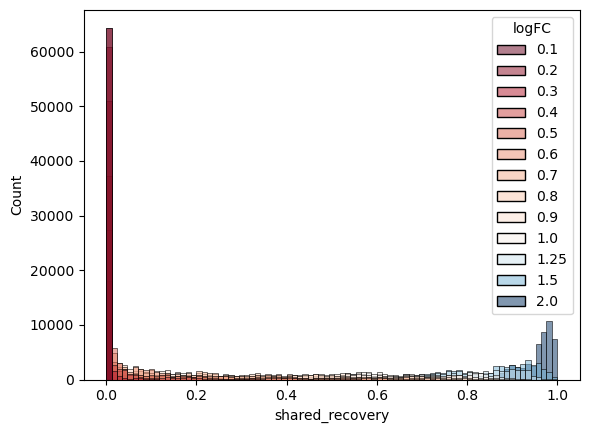

In [17]:
sns.histplot(results_df, x='shared_recovery', hue='logFC', palette='RdBu')